## Loan Approval - Credit Scoring

Goal: predict if a loan gets approved (`Loan_Status` = Y or N) from the applicant's data.

Dataset: `datasets/loan approval pred/train.csv`

In [37]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, confusion_matrix, classification_report, ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(10,5)
pd.set_option("display.width",200)
pd.set_option("display.max_columns",30)
RANDOM_STATE=42

In [38]:
df = pd.read_csv("datasets/loan approval pred/train.csv")
print("Shape:", df.shape)
print("Approval rate:", round((df.Loan_Status=='Y').mean()*100,1), "%")
print("\nMissing values per column:")
print(df.isna().sum()[df.isna().sum()>0].to_string())

Shape: (714, 13)
Approval rate: 66.1 %

Missing values per column:
Gender              13
Married              3
Dependents          15
Self_Employed       32
LoanAmount          22
Loan_Amount_Term    14
Credit_History      50


In [39]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


## 1. Looking at the data

See how each field relates to approval. A Credit_History of 1 should mean a good history.

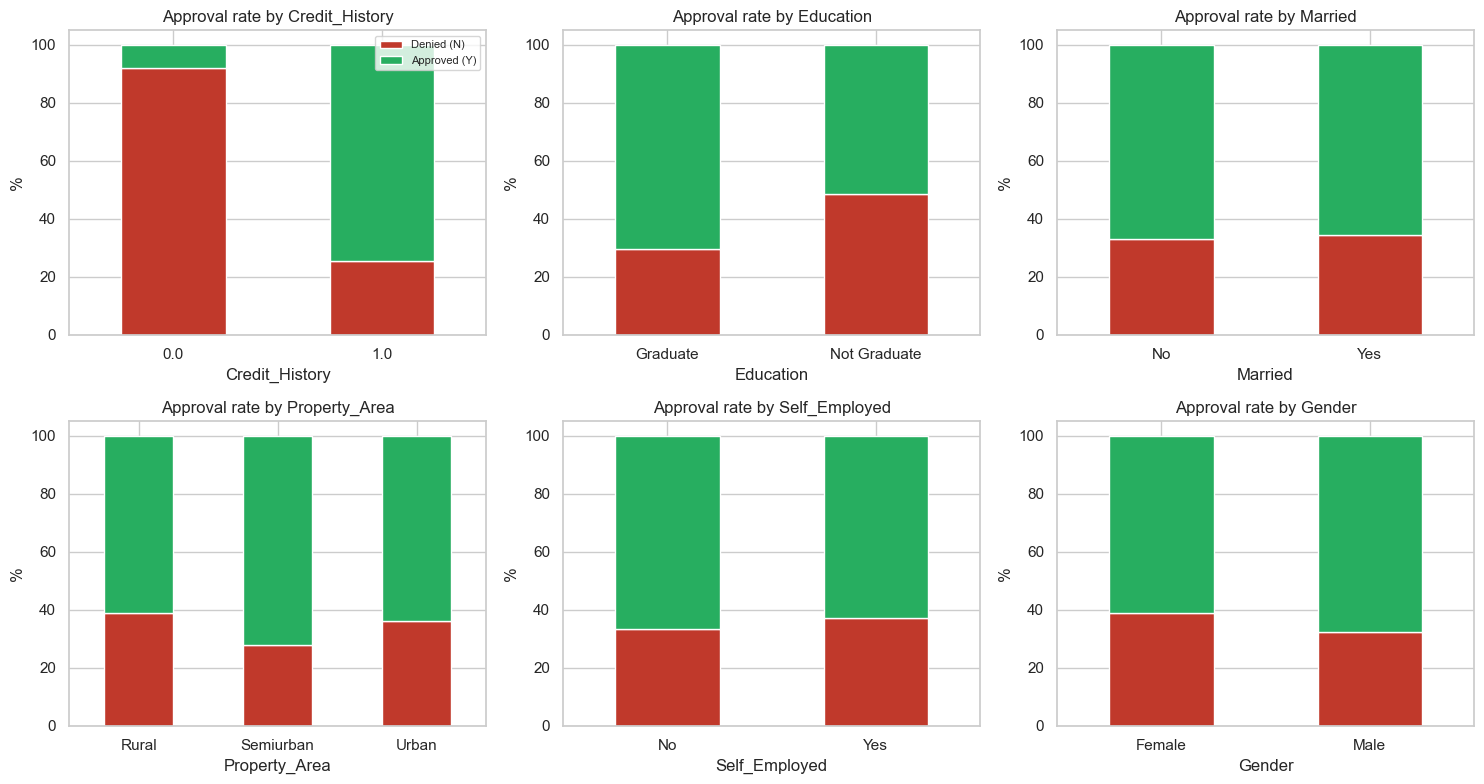

Approval rate by Credit_History:
Credit_History
0.0     7.9
1.0    74.4


In [40]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
cat = ["Credit_History","Education","Married","Property_Area","Self_Employed","Gender"]
for ax, c in zip(axes.ravel(), cat):
    tab = pd.crosstab(df[c], df["Loan_Status"], normalize="index")*100
    tab.plot(kind="bar", stacked=True, ax=ax, color=["#c0392b","#27ae60"], legend=False)
    ax.set_title(f"Approval rate by {c}"); ax.set_ylabel("%"); ax.tick_params(axis="x", rotation=0)
axes.ravel()[0].legend(["Denied (N)","Approved (Y)"], fontsize=8)
plt.tight_layout(); plt.show()

print("Approval rate by Credit_History:")
print((df.groupby('Credit_History')['Loan_Status'].apply(lambda s:(s=='Y').mean()*100)).round(1).to_string())

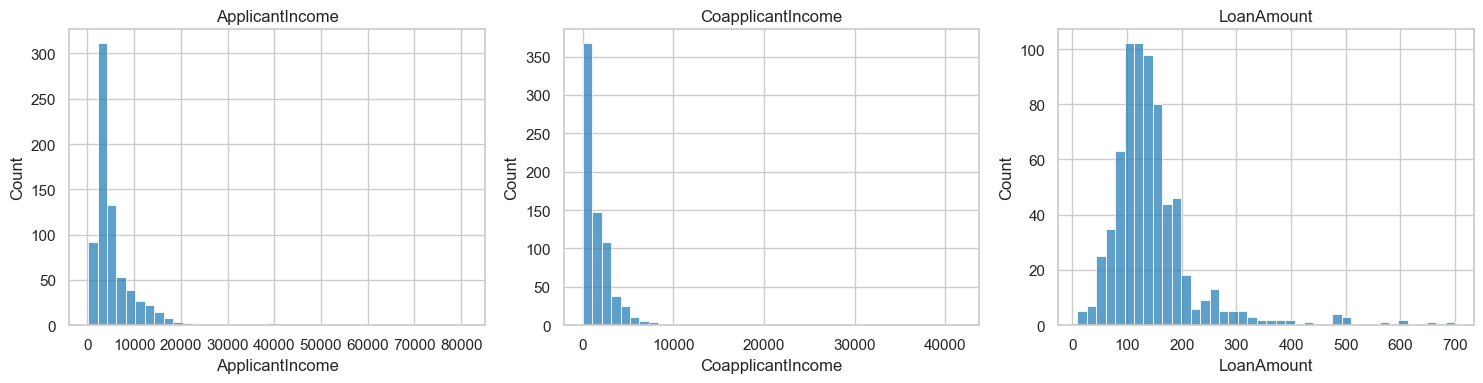

Skewness (a long tail means a log transform helps):
ApplicantIncome      5.98
CoapplicantIncome    7.81
LoanAmount           2.82


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, c in zip(axes, ["ApplicantIncome","CoapplicantIncome","LoanAmount"]):
    sns.histplot(df[c].dropna(), bins=40, ax=ax, color="#2980b9"); ax.set_title(c)
plt.tight_layout(); plt.show()
print("Skewness (a long tail means a log transform helps):")
print(df[["ApplicantIncome","CoapplicantIncome","LoanAmount"]].skew().round(2).to_string())

## 2. Fill missing values and build new features

Fill the gaps: text columns with the most common value, and `LoanAmount`, `Loan_Amount_Term` and `Credit_History` with the median or the most common value.

New features: total income, the log of the skewed columns, a rough monthly payment (EMI), and the income left after that payment. These give an idea of how easily the person can pay the loan back.

In [42]:
d = df.copy()
for c in ["Gender","Married","Dependents","Self_Employed"]:
    d[c] = d[c].fillna(d[c].mode()[0])
d["LoanAmount"] = d["LoanAmount"].fillna(d["LoanAmount"].median())
d["Loan_Amount_Term"] = d["Loan_Amount_Term"].fillna(d["Loan_Amount_Term"].mode()[0])
d["Credit_History"] = d["Credit_History"].fillna(d["Credit_History"].mode()[0])

# New features
d["Dependents"] = d["Dependents"].replace("3+","3").astype(int)
d["TotalIncome"] = d["ApplicantIncome"] + d["CoapplicantIncome"]
d["TotalIncome_log"] = np.log1p(d["TotalIncome"])
d["LoanAmount_log"] = np.log1p(d["LoanAmount"])
d["EMI"] = d["LoanAmount"] / d["Loan_Amount_Term"]        # rough monthly payment (in thousands)
d["Balance_Income"] = d["TotalIncome"] - d["EMI"]*1000    # income left after the payment

# Turn text into numbers
d["Loan_Status"] = (d["Loan_Status"]=="Y").astype(int)
for c,m in [("Gender",{"Male":1,"Female":0}),("Married",{"Yes":1,"No":0}),
            ("Education",{"Graduate":1,"Not Graduate":0}),("Self_Employed",{"Yes":1,"No":0})]:
    d[c]=d[c].map(m)
d = pd.get_dummies(d, columns=["Property_Area"], drop_first=True)

feat = ["Gender","Married","Dependents","Education","Self_Employed","Credit_History",
        "TotalIncome_log","LoanAmount_log","Loan_Amount_Term","EMI","Balance_Income"] + \
       [c for c in d.columns if c.startswith("Property_Area_")]
X = d[feat].astype(float); y = d["Loan_Status"]
print("Features:", feat); print("X:", X.shape)

Features: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'TotalIncome_log', 'LoanAmount_log', 'Loan_Amount_Term', 'EMI', 'Balance_Income', 'Property_Area_Semiurban', 'Property_Area_Urban']
X: (714, 13)


## 3. Train and compare models

Score the models with AUC and KS. Both show how well the model tells good payers apart from bad payers.

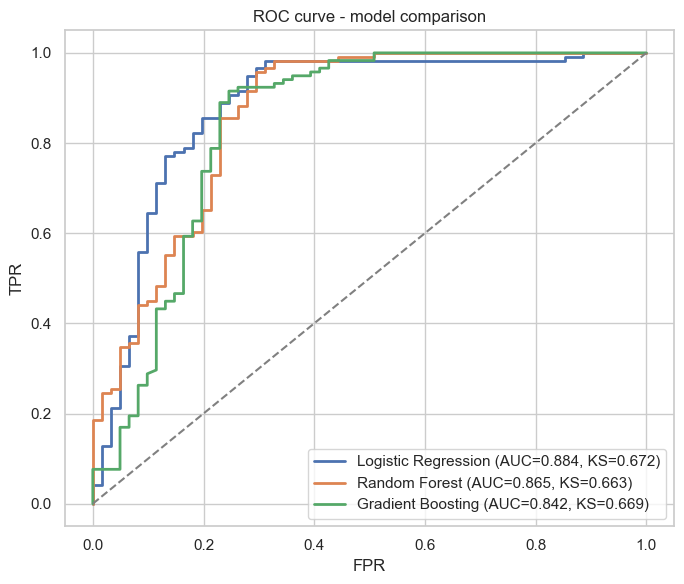

                       AUC     KS
Logistic Regression  0.884  0.672
Random Forest        0.865  0.663
Gradient Boosting    0.842  0.669


In [43]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE)
scaler = StandardScaler().fit(X_tr)
X_tr_s, X_te_s = scaler.transform(X_tr), scaler.transform(X_te)

def ks_stat(y_true, proba):
    fpr, tpr, _ = roc_curve(y_true, proba); return float(np.max(tpr-fpr))

models = {
    "Logistic Regression": (LogisticRegression(max_iter=1000, class_weight="balanced"), True),
    "Random Forest": (RandomForestClassifier(n_estimators=300, max_depth=6,
                       class_weight="balanced", random_state=RANDOM_STATE), False),
    "Gradient Boosting": (GradientBoostingClassifier(random_state=RANDOM_STATE), False),
}
results = {}
plt.figure(figsize=(7,6))
for name,(mdl,use_scaler) in models.items():
    Xtr_, Xte_ = (X_tr_s,X_te_s) if use_scaler else (X_tr,X_te)
    mdl.fit(Xtr_, y_tr)
    proba = mdl.predict_proba(Xte_)[:,1]
    auc, ks = roc_auc_score(y_te,proba), ks_stat(y_te,proba)
    results[name]={"AUC":round(auc,3),"KS":round(ks,3),"model":mdl,"proba":proba}
    fpr,tpr,_=roc_curve(y_te,proba)
    plt.plot(fpr,tpr,lw=2,label=f"{name} (AUC={auc:.3f}, KS={ks:.3f})")
plt.plot([0,1],[0,1],"--",color="gray"); plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC curve - model comparison"); plt.legend(); plt.tight_layout(); plt.show()

print(pd.DataFrame({k:{"AUC":v["AUC"],"KS":v["KS"]} for k,v in results.items()}).T.to_string())

Best model: Logistic Regression 

              precision    recall  f1-score   support

      Denied       0.75      0.77      0.76        61
    Approved       0.88      0.86      0.87       118

    accuracy                           0.83       179
   macro avg       0.81      0.82      0.81       179
weighted avg       0.83      0.83      0.83       179



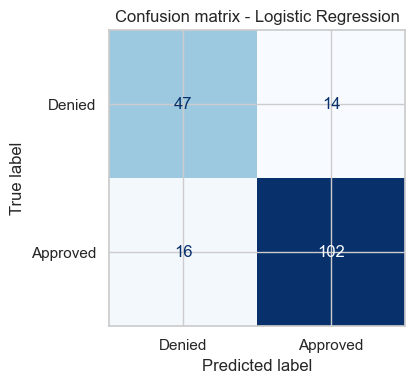

In [44]:
# Confusion matrix of the best model (by AUC)
best = max(results, key=lambda k: results[k]["AUC"])
proba = results[best]["proba"]; pred = (proba>=0.5).astype(int)
print("Best model:", best, "\n")
print(classification_report(y_te, pred, target_names=["Denied","Approved"]))
fig,ax=plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay(confusion_matrix(y_te,pred),
    display_labels=["Denied","Approved"]).plot(ax=ax,cmap="Blues",colorbar=False)
ax.set_title(f"Confusion matrix - {best}"); plt.tight_layout(); plt.show()

## 4. What drives the decision

Look at which features matter most, and whether each one pushes the answer toward approval or denial.

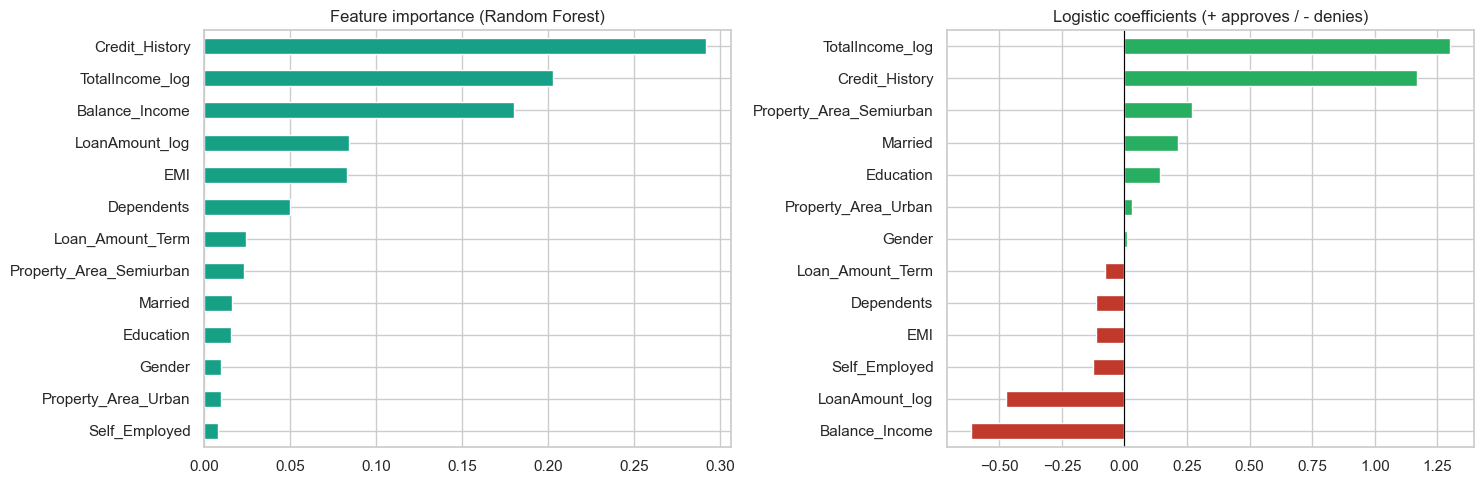

In [45]:
rf = results["Random Forest"]["model"]
imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
fig,(a1,a2)=plt.subplots(1,2,figsize=(15,5))
imp.plot(kind="barh", ax=a1, color="#16a085"); a1.set_title("Feature importance (Random Forest)")
logit = results["Logistic Regression"]["model"]
coef = pd.Series(logit.coef_[0], index=X.columns).sort_values()
coef.plot(kind="barh", ax=a2, color=["#c0392b" if v<0 else "#27ae60" for v in coef])
a2.set_title("Logistic coefficients (+ approves / - denies)"); a2.axvline(0,color="black",lw=0.8)
plt.tight_layout(); plt.show()

## 5. Choosing the cut-off

The 0.5 cut-off is just a default. Denying a good payer loses a sale, and approving a bad one causes a loss. The chart below shows how the cut-off changes the share of people approved and how good that group is.

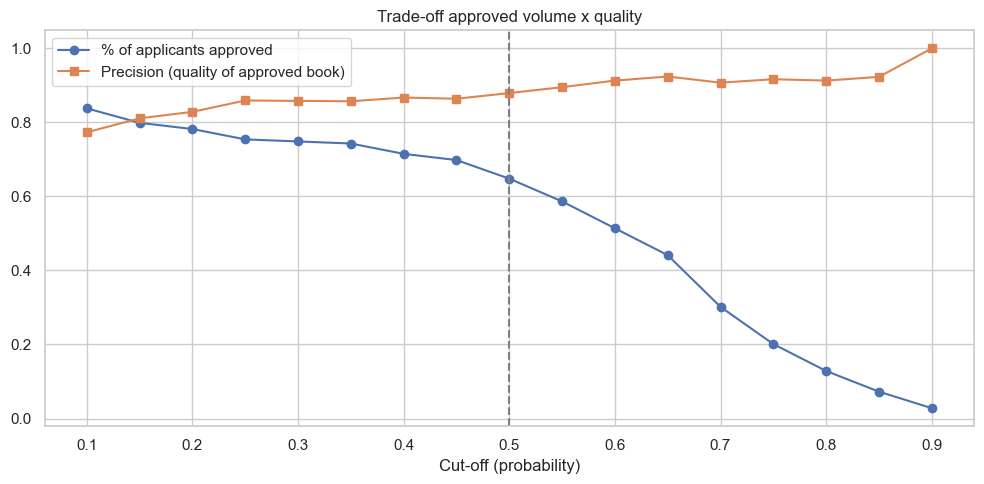

In [46]:
cuts = np.arange(0.1,0.91,0.05)
approval_rate, approval_precision = [], []
for t in cuts:
    p=(proba>=t).astype(int)
    approval_rate.append(p.mean())
    approval_precision.append((y_te[p==1]==1).mean() if p.sum()>0 else np.nan)
fig,ax=plt.subplots()
ax.plot(cuts,approval_rate,marker="o",label="% of applicants approved")
ax.plot(cuts,approval_precision,marker="s",label="Precision (quality of approved book)")
ax.axvline(0.5,color="gray",ls="--"); ax.set_xlabel("Cut-off (probability)")
ax.set_title("Trade-off approved volume x quality"); ax.legend(); plt.tight_layout(); plt.show()

## 6. Simulator

Fill the data and the decision model returns approved or denied, using the best tested model (AUC) from the code.

In [58]:
best_name        = max(results, key=lambda k: results[k]["AUC"])
best_model       = results[best_name]["model"]
best_uses_scaler = (best_name == "Logistic Regression")  

def simular_credito(perfil, threshold=0.5, verbose=True):
    g   = {"Male": 1, "Female": 0}[perfil["Gender"]]
    mar = {"Yes": 1, "No": 0}[perfil["Married"]]
    edu = {"Graduate": 1, "Not Graduate": 0}[perfil["Education"]]
    se  = {"Yes": 1, "No": 0}[perfil["Self_Employed"]]
    dep = min(int(str(perfil["Dependents"]).replace("3+", "3")), 3)   

    total_income = perfil["ApplicantIncome"] + perfil["CoapplicantIncome"]
    emi = perfil["LoanAmount"] / perfil["Loan_Amount_Term"]
    row = {
        "Gender": g, "Married": mar, "Dependents": dep, "Education": edu,
        "Self_Employed": se, "Credit_History": float(perfil["Credit_History"]),
        "TotalIncome_log": np.log1p(total_income),
        "LoanAmount_log":  np.log1p(perfil["LoanAmount"]),
        "Loan_Amount_Term": perfil["Loan_Amount_Term"],
        "EMI": emi,
        "Balance_Income": total_income - emi * 1000,
        "Property_Area_Semiurban": 1 if perfil["Property_Area"] == "Semiurban" else 0,
        "Property_Area_Urban":     1 if perfil["Property_Area"] == "Urban"     else 0,
    }
    x    = pd.DataFrame([row])[X.columns]                       
    x_in = scaler.transform(x) if best_uses_scaler else x
    proba    = float(best_model.predict_proba(x_in)[:, 1][0])
    aprovado = proba >= threshold

    if verbose:
        print(f"Used Model\t : {best_name}")
        print(f"Probability\t : {proba*100:5.1f}%   (cut = {threshold:.0%})")
        print(f"Decision\t : {'APPROVED' if aprovado else 'DENIED'}")
    return {"proba": proba, "approved": bool(aprovado), "modelo": best_name}

In [73]:
pessoa = {
    "Gender":            "Male",          # "Male" / "Female"
    "Married":           "Yes",           # "Yes" / "No"
    "Dependents":        10,               # 0, 1, 2, 3  (use 3 para "3 ou mais")
    "Education":         "Not Graduate",      # "Graduate" / "Not Graduate"
    "Self_Employed":     "No",            # "Yes" / "No"
    "ApplicantIncome":   2000,            # renda do solicitante
    "CoapplicantIncome": 1500,            # renda do co-solicitante (0 se nao houver)
    "LoanAmount":        300,             # (300 = 30.000)
    "Loan_Amount_Term":  10,             # prazo em meses
    "Credit_History":    1.0,             # 1.0 = bom historico | 0.0 = historico ruim
    "Property_Area":     "Urban",         # "Urban" / "Semiurban" / "Rural"
}

resultado = simular_credito(pessoa, threshold=0.5)

Used Model	 : Logistic Regression
Probability	 :   0.9%   (cut = 50%)
Decision	 : DENIED
